# Projet 5 — Flexion (CIVIL-321 MNSS)

Poutre 2D encastrée-appuyée sous charge transversale uniformément répartie.
Comparaison T3 / T6 / Euler-Bernoulli, convergence en h, analyse modale, piège FEM.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import matplotlib.pyplot as plt
from utils import *
from plot import *

## Paramètres globaux

Tous les paramètres physiques, géométriques et numériques sont rassemblés ici
pour pouvoir être ajustés rapidement par les correcteurs.


In [2]:
# === Matériau ===
MAT = {
    "E":   210e3,    # Module d'Young [N/mm^2]  (210 GPa pour acier)
    "nu":  0.3,      # Coefficient de Poisson [-]
    "rho": 9e-3,     # Masse volumique [kg/mm^2] (intégrée sur l'épaisseur)
    "plane_stress": True,  # True = contraintes planes, False = déformations planes
}

# === Géométrie poutre ===
GEOM = {
    "L":         1000.0,   # Longueur [mm]
    "h":         100.0,    # Hauteur [mm]
    "thickness": 10.0,     # Épaisseur hors-plan [mm]
}

# === Chargement ===
LOAD = {
    "q_total": 1000.0,     # Charge totale appliquée sur la longueur [N]
                           # (sera répartie => q_lin = q_total / L), constante quand h varie
}

# === Maillage / raffinement ===
MESH = {
    "order":      1,    # 1 => T3, 2 => T6
    "n_elem_L":   20,   # nombre d'éléments le long de la longueur
    "n_elem_h":   4,    # nombre d'éléments dans la hauteur
}

# === Étude paramétrique L/h ===
SLENDERNESS = {
    "ratios": [2, 5, 10, 20, 50, 100],   # L/h à balayer (h variable, L fixe)
}

# === Analyse modale ===
MODAL = {
    "n_modes": 5,    # nombre de fréquences propres à extraire
}

# === Convergence ===
CONVERGENCE = {
    "h_levels": [1, 2, 4, 8, 16, 32],   # facteurs de raffinement (multiplie n_elem)
}


### Fonctions pour construire la matrice de rigidité

La matrice D représente la loi constituve faisant le lien entre les déformations et les contraintes.

In [3]:
def calculerD(contraintes_planes=None):
    """Loi de comportement isotrope 2D (lit MAT par défaut)."""
    E  = MAT["E"]
    nu = MAT["nu"]
    if contraintes_planes is None:
        contraintes_planes = MAT["plane_stress"]

    if contraintes_planes:
        D = (E / (1 - nu**2)) * np.array([
            [1,  nu, 0],
            [nu, 1,  0],
            [0,  0,  (1 - nu) / 2],
        ])
    else:
        # Déformations planes
        coef = E / ((1 + nu) * (1 - 2 * nu))
        D = coef * np.array([
            [1 - nu, nu,     0],
            [nu,     1 - nu, 0],
            [0,      0,      (1 - 2 * nu) / 2],
        ])
    return D


La matrice C relie les déplacements en coordonnées réelles aux gradients en coordonnées naturelles

In [4]:
def calculerC():
    N1s, N1t = [-1, -1]
    N2s, N2t = [1, 0]
    N3s, N3t = [0, 1]
    C = np.array([
        [N1s, 0, N2s, 0, N3s, 0],
        [N1t, 0, N2t, 0, N3t, 0],
        [0, N1s, 0, N2s, 0, N3s],
        [0, N1t, 0, N2t, 0, N3t]])
    return C

La matrice B fait le lien entre les déplacements aux noeuds et les déformations dans l'élément. La matrice J est la matrice jacobienne du changement de coordonnées. 

In [5]:
def calculerBetJ(x, noeuds):
    C = calculerC()

    grads = C@noeuds.ravel()
    J = np.array([[grads[0], grads[2]],
                  [grads[1], grads[3]]])
    
    
    # Définition de A
    A = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 1, 0]
    ])

    # Définition de la matrice contenant les Jacobiennes
    Jblock = np.zeros((4, 4))
    Jblock[:2, :2] = J
    Jblock[2:, 2:] = J
    
    Mat_J = np.linalg.inv(Jblock)
    B = A@Mat_J@C
    return B, J

### Phase 2 — Élément T6 (quadratique iso-paramétrique)

Triangle quadratique à 6 nœuds (3 sommets + 3 nœuds médians sur arêtes).
Convention nœuds = celle de gmsh : `0,1,2` sommets, `3` milieu de l'arête `0-1`,
`4` milieu `1-2`, `5` milieu `2-0`.

En coordonnées d'aire $L_1 = 1-s-t$, $L_2 = s$, $L_3 = t$ :

$$
\begin{aligned}
N_1 &= L_1(2L_1-1) & N_4 &= 4 L_1 L_2 \\
N_2 &= L_2(2L_2-1) & N_5 &= 4 L_2 L_3 \\
N_3 &= L_3(2L_3-1) & N_6 &= 4 L_3 L_1
\end{aligned}
$$

La matrice $C(s,t)$ regroupe les dérivées $\partial N_i/\partial s$ et
$\partial N_i/\partial t$ ; le pattern $B = A \cdot J_{block}^{-1} \cdot C$ est
identique au T3, seules les tailles changent ($C: 4\times12$, $B: 3\times12$).

In [6]:
def gauss_triangle(npts):
    """Règles de Gauss sur le triangle de référence (somme des poids = 1/2 = aire)."""
    if npts == 1:
        # Degré 1 — exact pour T3 (B constant, J constant)
        return [(1/3, 1/3)], [1/2]
    if npts == 3:
        # Degré 2 — exact pour T6 K (B linéaire, J constant)
        quads   = [(1/6, 1/6), (2/3, 1/6), (1/6, 2/3)]
        weights = [1/6, 1/6, 1/6]
        return quads, weights
    if npts == 7:
        # Degré 5 — robuste pour T6 (masse, éléments distordus)
        a1, a2 = 0.0597158717, 0.4701420641
        w0     = 0.225 / 2
        w1     = 0.1323941527 / 2
        w2     = 0.1259391805 / 2
        quads   = [(1/3, 1/3),
                   (a1, a1), (1-2*a1, a1), (a1, 1-2*a1),
                   (a2, a2), (1-2*a2, a2), (a2, 1-2*a2)]
        weights = [w0, w1, w1, w1, w2, w2, w2]
        return quads, weights
    raise ValueError(f"Règle de Gauss à {npts} points non supportée (1, 3, 7).")


def calculerN_T6(X):
    """Matrice d'interpolation N(s,t) du T6 (shape 2x12)."""
    s, t = X[0], X[1]
    L1 = 1 - s - t
    Ns = [
        L1 * (2*L1 - 1),    # N1 (sommet 0)
        s  * (2*s  - 1),    # N2 (sommet 1)
        t  * (2*t  - 1),    # N3 (sommet 2)
        4 * s * L1,         # N4 (milieu 0-1)
        4 * s * t,          # N5 (milieu 1-2)
        4 * t * L1,         # N6 (milieu 2-0)
    ]
    N = np.zeros((2, 12))
    for i, Ni in enumerate(Ns):
        N[0, 2*i]   = Ni
        N[1, 2*i+1] = Ni
    return N


def calculerC_T6(X):
    """Matrice C(s,t) du T6 — gradients naturels des Ni (shape 4x12)."""
    s, t = X[0], X[1]
    # (dNi/ds, dNi/dt) dans l'ordre des nœuds gmsh
    dN = [
        (-3 + 4*s + 4*t, -3 + 4*s + 4*t),   # N1
        (4*s - 1,         0.0),             # N2
        (0.0,             4*t - 1),         # N3
        (4 - 8*s - 4*t,  -4*s),             # N4
        (4*t,             4*s),             # N5
        (-4*t,            4 - 4*s - 8*t),   # N6
    ]
    C = np.zeros((4, 12))
    for i, (dNs_i, dNt_i) in enumerate(dN):
        C[0, 2*i]   = dNs_i
        C[1, 2*i]   = dNt_i
        C[2, 2*i+1] = dNs_i
        C[3, 2*i+1] = dNt_i
    return C


def calculerBetJ_T6(X, noeuds):
    """Matrices B (déformations) et J (Jacobienne) au point (s,t) pour un T6."""
    C = calculerC_T6(X)

    grads = C @ noeuds.ravel()              # [dx/ds, dx/dt, dy/ds, dy/dt]
    J = np.array([[grads[0], grads[2]],
                  [grads[1], grads[3]]])

    A = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 1, 0],
    ])

    Jblock = np.zeros((4, 4))
    Jblock[:2, :2] = J
    Jblock[2:, 2:] = J

    B = A @ np.linalg.inv(Jblock) @ C
    return B, J

Calcul de la matrice de rigidité d'un unique élément

In [7]:
def calculerMatriceRigiditeLocale(connectivite_element, coordonnees):
    """Matrice de rigidité locale T3 ou T6 (dispatch sur le nb de nœuds)."""
    n_n    = connectivite_element.shape[0]
    noeuds = coordonnees[connectivite_element.ravel(), :]

    if n_n == 3:
        quads, weights = gauss_triangle(1)
        BJ_fn          = calculerBetJ
        ndof           = 6
    elif n_n == 6:
        quads, weights = gauss_triangle(3)
        BJ_fn          = calculerBetJ_T6
        ndof           = 12
    else:
        raise ValueError(f"Élément à {n_n} nœuds non supporté (T3=3, T6=6).")

    K_local = np.zeros((ndof, ndof))
    D       = calculerD()

    for x_q, w_q in zip(quads, weights):
        B, J = BJ_fn(x_q, noeuds)
        detJ = np.linalg.det(J)
        K_local += w_q * B.T @ D @ B * detJ

    return GEOM["thickness"] * K_local

Permet de relier les degrés de liberté à leur position (ligne et colonne associées) dans les matrices K et M

In [8]:
def calculerNumerosEquations(connectivite):

    n_elem  = connectivite.shape[0]
    n_nodes_per_elem = connectivite.shape[1]
    numEq = np.zeros((n_elem, 2*n_nodes_per_elem), dtype=int)
    for e in range(n_elem):
        for i in range(n_nodes_per_elem):
            numEq[e, 2*i]   = 2*connectivite[e, i];
            numEq[e, 2*i+1] = 2*connectivite[e, i]+1;
    return numEq

Assemble les matrices locales en une matrice globale

In [9]:
def assemblerMatriceRigidite(connectivite, coordonnees):

    n_elem  = connectivite.shape[0]
    n_nodes = coordonnees.shape[0]
    numEq = calculerNumerosEquations(connectivite)

    K = np.zeros((n_nodes*2, n_nodes*2))
    for e in range(n_elem):
        # On récupère les degrés de liberté de l'élément e
        ddl = numEq[e, :]
        # On récupère les noeuds de l'élément e
        connectivite_element = connectivite[e, :]
        # On calcule la matrice de rigidite locale de l'élément e
        K_locale = calculerMatriceRigiditeLocale(connectivite_element, coordonnees)
        # On assemble
        for i, gi in enumerate(ddl):
            for j, gj in enumerate(ddl):
                K[gi, gj] += K_locale[i, j]
    return K

## Fonction pour contruire la matrice de masse

Permet d'interpoler une valeur à la position X dans l'élément (en coordonnées naturelles) à partir des valeurs aux noeuds

In [10]:
def calculerN(X):
    """Matrice d'interpolation N(s,t) du T3 (shape 2x6)."""
    s = X[0]
    t = X[1]
    N1 = 1 - s - t
    N2 = s
    N3 = t
    return np.array([[N1, 0, N2, 0, N3, 0],
                     [0, N1, 0, N2, 0, N3]])

Calcul de la matrice de masse d'un unique élément

In [11]:
def calculerMatriceMasseLocale(connectivite_element, coordonnees):
    """Matrice de masse locale T3 ou T6 (dispatch sur le nb de nœuds)."""
    rho    = MAT["rho"]
    n_n    = connectivite_element.shape[0]
    noeuds = coordonnees[connectivite_element.ravel(), :]

    if n_n == 3:
        quads, weights = gauss_triangle(3)
        N_fn, BJ_fn    = calculerN,    calculerBetJ
        ndof           = 6
    elif n_n == 6:
        # 7 points car N est quadratique => N^T N est de degré 4
        quads, weights = gauss_triangle(7)
        N_fn, BJ_fn    = calculerN_T6, calculerBetJ_T6
        ndof           = 12
    else:
        raise ValueError(f"Élément à {n_n} nœuds non supporté (T3=3, T6=6).")

    M_local = np.zeros((ndof, ndof))

    for x_q, w_q in zip(quads, weights):
        N    = N_fn(x_q)
        B, J = BJ_fn(x_q, noeuds)
        detJ = np.linalg.det(J)
        M_local += w_q * rho * N.T @ N * detJ

    return GEOM["thickness"] * M_local

Assemble les matrices locales en une matrice globale

In [12]:
def assemblerMatriceMasse(connectivite, coordonnees):

    n_elem  = connectivite.shape[0]
    n_nodes = coordonnees.shape[0]
    numEq = calculerNumerosEquations(connectivite)

    M = np.zeros((n_nodes*2, n_nodes*2))
    for e in range(n_elem):
        # On récupère les degrés de liberté de l'élément e
        ddl = numEq[e, :]
        # On récupère les noeuds de l'élément e
        connectivite_element = connectivite[e, :]
        # On calcule la matrice de rigidite locale de l'élément e
        M_locale = calculerMatriceMasseLocale(connectivite_element, coordonnees)
        # On assemble
        for i, gi in enumerate(ddl):
            for j, gj in enumerate(ddl):
                M[gi, gj] += M_locale[i, j]
    return M

### Smoke-test Phase 2 — T3 et T6

Vérifie sur un triangle isolé que les briques bas-niveau sont cohérentes :
- $K$ et $M$ symétriques,
- 3 modes rigides ($K$ a 3 valeurs propres ≈ 0 — 2 translations + 1 rotation),
- $M$ définie positive (toutes les valeurs propres > 0).

Pas besoin de gmsh ici : maillage forgé à la main pour isoler la Phase 2.

In [13]:
def _check_element(coords, conn, label):
    K = assemblerMatriceRigidite(conn, coords)
    M = assemblerMatriceMasse(conn, coords)

    assert np.allclose(K, K.T), f"{label}: K non symétrique"
    assert np.allclose(M, M.T), f"{label}: M non symétrique"

    eigK = np.sort(np.linalg.eigvalsh(K))
    eigM = np.sort(np.linalg.eigvalsh(M))

    tolK    = 1e-6 * eigK.max()
    n_zeros = int(np.sum(np.abs(eigK) < tolK))
    assert n_zeros == 3, f"{label}: {n_zeros} modes rigides au lieu de 3"
    assert eigK[3] > 0,  f"{label}: K non semi-définie positive (eig[3]={eigK[3]:.2e})"
    assert eigM[0] > 0,  f"{label}: M non définie positive (min eig={eigM[0]:.2e})"

    print(f"{label}: K {K.shape} sym ok, modes rigides=3, "
          f"min eig K nontrivial={eigK[3]:.3e}, min eig M={eigM[0]:.3e}")


# --- T3 : un triangle (régression) ---
coords_t3 = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])
conn_t3   = np.array([[0, 1, 2]])
_check_element(coords_t3, conn_t3, "T3")

# --- T6 : un triangle quadratique (Phase 2) ---
coords_t6 = np.array([
    [0.0, 0.0],   # 0  sommet
    [1.0, 0.0],   # 1  sommet
    [0.0, 1.0],   # 2  sommet
    [0.5, 0.0],   # 3  milieu 0-1
    [0.5, 0.5],   # 4  milieu 1-2
    [0.0, 0.5],   # 5  milieu 2-0
])
conn_t6 = np.array([[0, 1, 2, 3, 4, 5]])
_check_element(coords_t6, conn_t6, "T6")

T3: K (6, 6) sym ok, modes rigides=3, min eig K nontrivial=1.007e+06, min eig M=3.750e-03
T6: K (12, 12) sym ok, modes rigides=3, min eig K nontrivial=1.688e+05, min eig M=2.300e-03


---

## Phase 3 — Patch test

Un champ de déplacement linéaire engendre un état de déformation $\varepsilon$ et de
contrainte $\sigma$ constants. On vérifie que T3 et T6 reproduisent à l'erreur
machine la solution analytique pour :

- **Traction uniaxiale** $\sigma_{xx} = \bar\sigma$, $\sigma_{yy} = \tau_{xy} = 0$
- **Cisaillement uniforme** $\tau_{xy} = \bar\tau$, $\sigma_{xx} = \sigma_{yy} = 0$

Géométrie fig. 10 : carré $[0, L]\times[0, h]$ découpé en 4 triangles autour
d'un nœud central **excentré**. Les nœuds médians du T6 sont placés au
milieu géométrique des arêtes (les arêtes intérieures héritent de
l'excentrement).

Méthode : Dirichlet pur — on impose le champ analytique aux nœuds frontières
et on résout pour les nœuds intérieurs ($K_{ii}\,u_i = -K_{ib}\,u_b$). Si
l'élément reproduit exactement les champs linéaires, l'erreur sur les DDL
intérieurs et la déformation aux points de Gauss tend vers la précision
machine.

In [14]:
def patch_mesh(order=1, L=2.0, h=1.0, cx_frac=0.6, cy_frac=0.55):
    """Maillage fig. 10 : 4 triangles autour d'un nœud central excentré.

    order=1 -> T3 (5 nœuds).
    order=2 -> T6 (13 nœuds : 5 + 4 milieux extérieurs + 4 milieux intérieurs).
    """
    corners = [
        np.array([0.0, 0.0]),    # 0 SW
        np.array([L,   0.0]),    # 1 SE
        np.array([L,   h  ]),    # 2 NE
        np.array([0.0, h  ]),    # 3 NW
    ]
    center = np.array([cx_frac * L, cy_frac * h])  # 4 — excentré

    if order == 1:
        coords = np.vstack([*corners, center])
        conn   = np.array([
            [0, 1, 4],
            [1, 2, 4],
            [2, 3, 4],
            [3, 0, 4],
        ])
        return coords, conn

    # T6 : milieu géométrique de chaque arête
    coords_list = [*corners, center]
    mid = {}
    edges = [(0, 1), (1, 2), (2, 3), (3, 0),
             (0, 4), (1, 4), (2, 4), (3, 4)]
    for a, b in edges:
        idx = len(coords_list)
        coords_list.append(0.5 * (coords_list[a] + coords_list[b]))
        mid[(a, b)] = mid[(b, a)] = idx

    coords = np.array(coords_list)
    conn = np.array([
        # convention gmsh : sommets puis milieux (0-1, 1-2, 2-0)
        [a, b, 4, mid[(a, b)], mid[(b, 4)], mid[(a, 4)]]
        for a, b in [(0, 1), (1, 2), (2, 3), (3, 0)]
    ])
    return coords, conn


def analytical_field(coords, mode, sigma=100.0, tau=50.0):
    """Champ de déplacement linéaire associé à un état (ε, σ) uniforme."""
    E, nu = MAT["E"], MAT["nu"]
    if mode == "traction":
        eps_xx =  sigma / E
        eps_yy = -nu * sigma / E
        u = eps_xx * coords[:, 0]
        v = eps_yy * coords[:, 1]
    elif mode == "shear":
        G     = E / (2 * (1 + nu))
        gamma = tau / G              # γ_xy = 2 ε_xy
        u = (gamma / 2) * coords[:, 1]
        v = (gamma / 2) * coords[:, 0]
    else:
        raise ValueError(f"mode inconnu : {mode}")
    return np.column_stack([u, v]).ravel()


def strain_target(mode, sigma=100.0, tau=50.0):
    """État de déformation uniforme attendu (ε_xx, ε_yy, γ_xy)."""
    E, nu = MAT["E"], MAT["nu"]
    if mode == "traction":
        return np.array([sigma / E, -nu * sigma / E, 0.0])
    if mode == "shear":
        G = E / (2 * (1 + nu))
        return np.array([0.0, 0.0, tau / G])
    raise ValueError(mode)


def boundary_nodes(coords, L, h, tol=1e-9):
    """Indices des nœuds situés sur le bord du rectangle [0,L]x[0,h]."""
    x, y = coords[:, 0], coords[:, 1]
    on_bnd = (np.abs(x) < tol) | (np.abs(x - L) < tol) \
           | (np.abs(y) < tol) | (np.abs(y - h) < tol)
    return np.where(on_bnd)[0]


def max_strain_error(coords, conn, u, eps_target):
    """Évalue ε = B·u_elem aux points de Gauss et renvoie max |ε - ε_target|."""
    err = 0.0
    n_n = conn.shape[1]
    if n_n == 3:
        quads, _ = gauss_triangle(1)
        BJ_fn    = calculerBetJ
    else:
        quads, _ = gauss_triangle(3)
        BJ_fn    = calculerBetJ_T6

    eq = calculerNumerosEquations(conn)
    for e in range(conn.shape[0]):
        noeuds  = coords[conn[e].ravel(), :]
        u_local = u[eq[e, :]]
        for x_q in quads:
            B, _ = BJ_fn(x_q, noeuds)
            eps = B @ u_local
            err = max(err, np.max(np.abs(eps - eps_target)))
    return err


def patch_test(order, mode, L=2.0, h=1.0):
    """Lance un patch test et retourne (err_disp, err_strain, ...)."""
    coords, conn = patch_mesh(order, L=L, h=h)
    K            = assemblerMatriceRigidite(conn, coords)

    u_anal = analytical_field(coords, mode)
    n_dof  = u_anal.size

    bnd_nodes = boundary_nodes(coords, L, h)
    bnd_dofs  = np.concatenate([[2*n, 2*n+1] for n in bnd_nodes])
    free_dofs = np.setdiff1d(np.arange(n_dof), bnd_dofs)

    u = u_anal.copy()
    rhs = -K[np.ix_(free_dofs, bnd_dofs)] @ u_anal[bnd_dofs]
    u[free_dofs] = np.linalg.solve(K[np.ix_(free_dofs, free_dofs)], rhs)

    err_disp   = float(np.max(np.abs(u - u_anal)))
    err_strain = max_strain_error(coords, conn, u, strain_target(mode))

    return err_disp, err_strain, u, u_anal, coords, conn

Note: T6 elements are subdivided into 4 T3 sub-triangles for plotting. Mesh lines will appear denser than the actual element count.


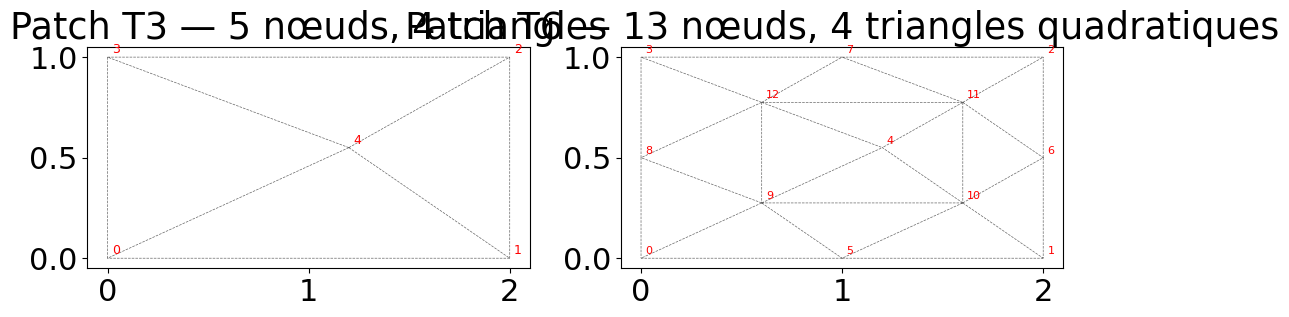

In [15]:
# Visualisation des maillages fig. 10 (centre excentré)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plt.sca(axes[0])
coords_p3, conn_p3 = patch_mesh(order=1)
plotMesh(coords_p3, conn_p3)
axes[0].set_title("Patch T3 — 5 nœuds, 4 triangles")
for i, (x, y) in enumerate(coords_p3):
    axes[0].annotate(str(i), (x, y), color="red", fontsize=9,
                     xytext=(3, 3), textcoords="offset points")

plt.sca(axes[1])
coords_p6, conn_p6 = patch_mesh(order=2)
plotMesh(coords_p6, conn_p6)
axes[1].set_title("Patch T6 — 13 nœuds, 4 triangles quadratiques")
for i, (x, y) in enumerate(coords_p6):
    axes[1].annotate(str(i), (x, y), color="red", fontsize=8,
                     xytext=(3, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

In [16]:
cases = [
    (1, "traction"),
    (1, "shear"),
    (2, "traction"),
    (2, "shear"),
]

# Tolérances : T3 atteint la précision machine, T6 un poil plus haut à cause
# de l'inversion K_ii sur 16 DDL libres et la quadrature 3 points.
TOL = {1: 1e-12, 2: 1e-10}

print(f"{'cas':<18} {'err_disp':>12}   {'err_strain':>12}")
print("-" * 46)

for order, mode in cases:
    err_d, err_s, *_ = patch_test(order, mode)
    label = f"T{3 if order == 1 else 6} {mode}"
    print(f"{label:<18} {err_d:12.3e}   {err_s:12.3e}")
    assert err_d < TOL[order], f"{label}: err_disp={err_d:.2e} >= tol {TOL[order]:.0e}"
    assert err_s < TOL[order], f"{label}: err_strain={err_s:.2e} >= tol {TOL[order]:.0e}"

print("\nOK Phase 3 — patch test passé pour T3 et T6, traction et cisaillement.")

cas                    err_disp     err_strain
----------------------------------------------
T3 traction           1.355e-20      2.168e-19
T3 shear              5.421e-20      2.168e-19
T6 traction           2.168e-19      8.707e-19
T6 shear              1.626e-19      6.505e-19

OK Phase 3 — patch test passé pour T3 et T6, traction et cisaillement.


---

## Phase 4 — Poutre encastrée-appuyée (propped cantilever)

On modélise une poutre 2D `[0, L] × [0, h]`, **encastrée en `x = 0`** et
**simplement appuyée en `x = L`** (appui ponctuel sur l'axe neutre $y = h/2$).

Charge transversale uniformément répartie sur le bord supérieur :
$q_\text{lin} = q_\text{total}/L$ [N/mm], totale constante quand $h$ varie
(énoncé du sujet).

Maillage **structuré maison** (sans gmsh, indisponible dans la venv) :
$n_x \times n_y$ cellules, chacune découpée en 2 triangles (diagonale
alternée pour ne pas biaiser une direction). Pour T6, on enrichit chaque
triangle par 3 nœuds milieux d'arête.

Solution analytique de référence — Euler-Bernoulli pour propped cantilever :

$$
v(x) = \frac{qL^4}{48\,EI}\,\xi^2\,(3 - 5\xi + 2\xi^2),\qquad \xi = \frac{x}{L}
$$

Flèche maximale en $\xi^* = (15 - \sqrt{33})/16 \approx 0.5785$, soit
$v_\text{max} \approx qL^4 / (184.6\,EI)$. Moment d'encastrement
$M(0) = -qL^2/8$.

Avec les paramètres par défaut ($L=1000$ mm, $h=100$ mm, $t=10$ mm,
$E=210$ GPa, $q=1$ N/mm), $EI = E\cdot t\,h^3/12 = 1.75 \times 10^{11}$
N·mm² et $v_\text{max} \approx 0.031$ mm.

Maillage poutre : T3 — 160 éléments, 105 nœuds (grille 20x4)


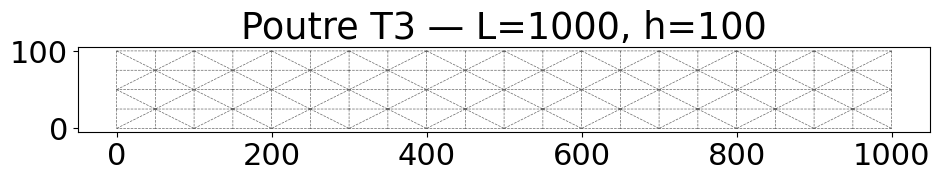

In [17]:
def mesh_rect_t3(L, h, nx, ny):
    """Maillage rectangulaire structuré T3 (nx*ny cellules, 2 triangles chacune)."""
    xs = np.linspace(0.0, L, nx + 1)
    ys = np.linspace(0.0, h, ny + 1)
    coords = np.array([[x, y] for y in ys for x in xs])
    nidx = lambda i, j: j * (nx + 1) + i
    conn = []
    for j in range(ny):
        for i in range(nx):
            a, b = nidx(i, j),     nidx(i + 1, j)
            c, d = nidx(i, j + 1), nidx(i + 1, j + 1)
            # Diagonale alternée pour éviter un biais directionnel
            if (i + j) % 2 == 0:
                conn += [[a, b, d], [a, d, c]]
            else:
                conn += [[a, b, c], [b, d, c]]
    return coords, np.array(conn, dtype=int)


def mesh_rect_t6(L, h, nx, ny):
    """Maillage T6 : T3 enrichi de 3 nœuds milieux d'arête par triangle."""
    coords3, conn3 = mesh_rect_t3(L, h, nx, ny)
    coords_list = [tuple(p) for p in coords3]
    edge_idx = {}

    def mid(a, b):
        key = tuple(sorted((a, b)))
        if key not in edge_idx:
            edge_idx[key] = len(coords_list)
            coords_list.append(tuple(0.5 * (coords3[a] + coords3[b])))
        return edge_idx[key]

    conn6 = [[a, b, c, mid(a, b), mid(b, c), mid(c, a)]
             for a, b, c in conn3]
    return np.array(coords_list), np.array(conn6, dtype=int)


def build_beam_mesh(L=None, h=None, nx=None, ny=None, order=None):
    """Construit le maillage de la poutre selon les paramètres globaux."""
    L     = L     if L     is not None else GEOM["L"]
    h     = h     if h     is not None else GEOM["h"]
    nx    = nx    if nx    is not None else MESH["n_elem_L"]
    ny    = ny    if ny    is not None else MESH["n_elem_h"]
    order = order if order is not None else MESH["order"]
    if order == 1:
        return mesh_rect_t3(L, h, nx, ny)
    if order == 2:
        return mesh_rect_t6(L, h, nx, ny)
    raise ValueError(f"order {order} non supporté (1 ou 2)")


# Visualisation du maillage poutre
coords_b, conn_b = build_beam_mesh()
elem_label = f"T{3 if conn_b.shape[1] == 3 else 6}"
print(f"Maillage poutre : {elem_label} — "
      f"{conn_b.shape[0]} éléments, {coords_b.shape[0]} nœuds "
      f"(grille {MESH['n_elem_L']}x{MESH['n_elem_h']})")

plt.figure(figsize=(11, 2.5))
plotMesh(coords_b, conn_b)
plt.title(f"Poutre {elem_label} — L={GEOM['L']:.0f}, h={GEOM['h']:.0f}")
plt.show()

In [18]:
def calculerBlocages(coords, L=None, h=None, tol=1e-6):
    """Encastrement gauche (x=0) + appui simple ponctuel sur l'axe neutre à x=L."""
    L = L if L is not None else GEOM["L"]
    h = h if h is not None else GEOM["h"]

    bloc = np.zeros((coords.shape[0], 2), dtype=bool)
    bloc[np.abs(coords[:, 0]) < tol, :] = True   # encastrement complet à gauche

    right = np.where(np.abs(coords[:, 0] - L) < tol)[0]
    pivot = right[np.argmin(np.abs(coords[right, 1] - h / 2))]
    bloc[pivot, 1] = True                        # uy=0 sur axe neutre droit

    return bloc.ravel()


def calculerF(coords, conn, L=None, h=None, q_total=None, tol=1e-6):
    """Forces consistantes pour une charge linéique q_lin = q_total/L sur y=h."""
    L       = L       if L       is not None else GEOM["L"]
    h       = h       if h       is not None else GEOM["h"]
    q_total = q_total if q_total is not None else LOAD["q_total"]
    q_lin   = q_total / L

    F = np.zeros(coords.shape[0] * 2)
    on_top = np.abs(coords[:, 1] - h) < tol

    n_n = conn.shape[1]
    if n_n == 3:
        edges = [(0, 1), (1, 2), (2, 0)]
        wfn = lambda Le: (Le / 2, Le / 2)            # N linéaire => trapèze
    else:
        # T6 : milieux d'arête aux indices 3 (0-1), 4 (1-2), 5 (2-0)
        edges = [(0, 1, 3), (1, 2, 4), (2, 0, 5)]
        wfn = lambda Le: (Le / 6, Le / 6, 4 * Le / 6)  # N quadratique => Simpson

    for e in range(conn.shape[0]):
        for edge in edges:
            ids = [conn[e, k] for k in edge]
            if all(on_top[i] for i in ids):
                a, b = ids[0], ids[1]
                Le   = np.linalg.norm(coords[b] - coords[a])
                w    = wfn(Le)
                for k, i in enumerate(ids):
                    F[2 * i + 1] -= q_lin * w[k]
    return F


def solve_beam(coords, conn):
    """Assemble K, F, applique les blocages homogènes et résout."""
    K        = assemblerMatriceRigidite(conn, coords)
    F        = calculerF(coords, conn)
    blocages = calculerBlocages(coords)
    libres   = ~blocages

    u = np.zeros(coords.shape[0] * 2)
    u[libres] = np.linalg.solve(K[np.ix_(libres, libres)], F[libres])
    return u, K, F


u, K, F = solve_beam(coords_b, conn_b)

# Vérifications de cohérence
F_total_y = F[1::2].sum()
print(f"Force verticale totale appliquée : {F_total_y:.4e} N "
      f"(attendu {-LOAD['q_total']:.4e})")
n_libres = (~calculerBlocages(coords_b)).sum()
print(f"DDL libres : {n_libres} / {2*coords_b.shape[0]}")

Force verticale totale appliquée : -1.0000e+03 N (attendu -1.0000e+03)
DDL libres : 199 / 210


=== Flèche poutre (propped cantilever) ===
v(L/2)  EB    : -2.9762e-02 mm
v(L/2)  FEM   : -2.3671e-02 mm  (err 20.47 %)
v_max   EB    : -3.0949e-02 mm  en x = 578.5 mm
v_max   FEM   : -2.4406e-02 mm  en x = 600.0 mm
M(0)    EB    : -1.2500e+05 N.mm  (encastrement)


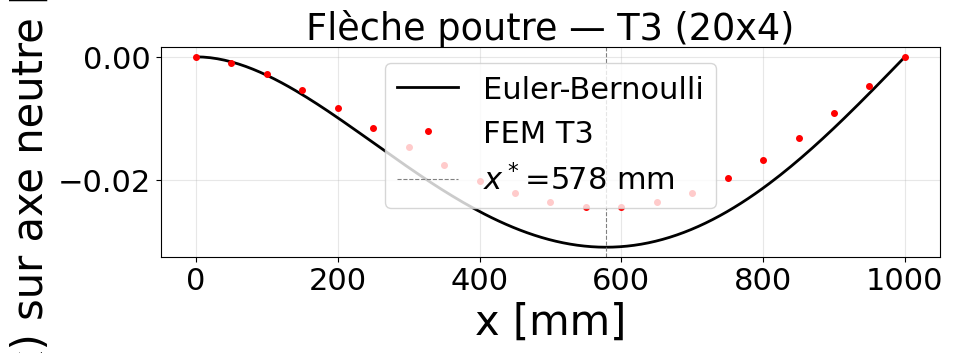

In [19]:
def eb_M(x, q_lin, L):
    """Moment fléchissant Euler-Bernoulli pour propped cantilever."""
    xi = x / L
    return q_lin * L**2 / 8 * (5 * xi - 1 - 4 * xi**2)


def eb_v(x, q_lin, L, EI):
    """Flèche Euler-Bernoulli (positive vers le bas pour q vers le bas)."""
    xi = x / L
    # Convention : v_FEM est uy (vers le haut). Le chargement q est vers le bas
    # donc on s'attend à uy < 0. eb_v retourne une valeur négative.
    return -q_lin * L**4 / (48 * EI) * xi**2 * (3 - 5 * xi + 2 * xi**2)


def eb_sigma_xx(x, y_nat, q_lin, L, h, t):
    """Contrainte de flexion EB. y_nat mesuré depuis l'axe neutre."""
    I = t * h**3 / 12
    return -eb_M(x, q_lin, L) * y_nat / I


# Constantes EB
E, nu, t = MAT["E"], MAT["nu"], GEOM["thickness"]
L_b, h_b = GEOM["L"], GEOM["h"]
q_lin    = LOAD["q_total"] / L_b
I_b      = t * h_b**3 / 12
EI_b     = E * I_b

# Position de la flèche maximale (ξ* = (15 - sqrt(33))/16)
xi_star  = (15 - np.sqrt(33)) / 16
x_max_eb = xi_star * L_b
v_max_eb = eb_v(x_max_eb, q_lin, L_b, EI_b)
v_mid_eb = eb_v(L_b / 2, q_lin, L_b, EI_b)

# Extraction de la flèche FEM sur l'axe neutre
y_axis = h_b / 2
on_axis = np.where(np.abs(coords_b[:, 1] - y_axis) < 1e-6)[0]
order_axis = np.argsort(coords_b[on_axis, 0])
x_axis = coords_b[on_axis[order_axis], 0]
v_axis = u[2 * on_axis[order_axis] + 1]

# Flèche FEM à mi-portée
mid_idx     = np.argmin(np.abs(x_axis - L_b / 2))
v_mid_fem   = v_axis[mid_idx]
v_max_fem   = v_axis[np.argmin(v_axis)]   # flèche la plus négative
x_max_fem   = x_axis[np.argmin(v_axis)]

print("=== Flèche poutre (propped cantilever) ===")
print(f"v(L/2)  EB    : {v_mid_eb:+.4e} mm")
print(f"v(L/2)  FEM   : {v_mid_fem:+.4e} mm  (err {abs(v_mid_fem-v_mid_eb)/abs(v_mid_eb)*100:.2f} %)")
print(f"v_max   EB    : {v_max_eb:+.4e} mm  en x = {x_max_eb:.1f} mm")
print(f"v_max   FEM   : {v_max_fem:+.4e} mm  en x = {x_max_fem:.1f} mm")
print(f"M(0)    EB    : {eb_M(0, q_lin, L_b):+.4e} N.mm  (encastrement)")

# Profil v(x) : FEM vs EB
xs_eb = np.linspace(0, L_b, 200)
plt.figure(figsize=(10, 4))
plt.plot(xs_eb, eb_v(xs_eb, q_lin, L_b, EI_b),
         "k-",  label="Euler-Bernoulli", lw=2)
plt.plot(x_axis, v_axis,
         "ro", ms=4, label=f"FEM {elem_label}")
plt.axvline(x_max_eb, color="gray", ls="--", lw=0.8,
            label=fr"$x^*\!=\!{x_max_eb:.0f}$ mm")
plt.xlabel("x [mm]")
plt.ylabel("v(x) sur axe neutre [mm]")
plt.title(f"Flèche poutre — {elem_label} ({MESH['n_elem_L']}x{MESH['n_elem_h']})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

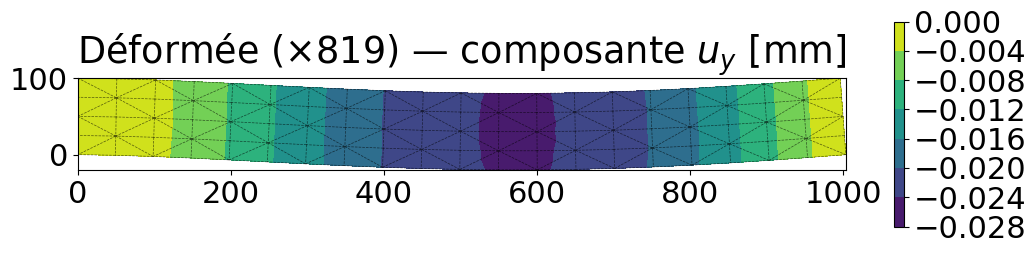

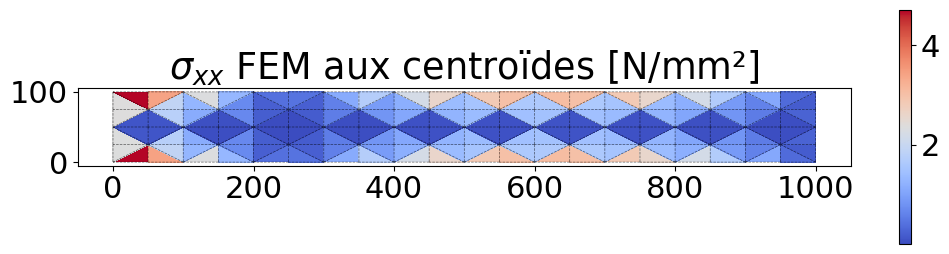

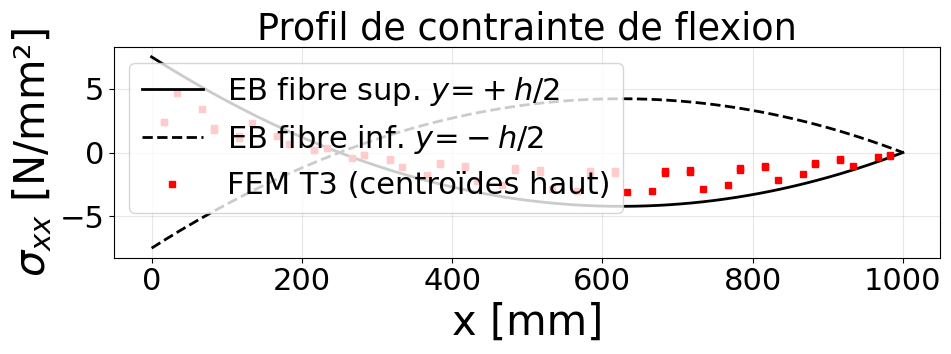

In [20]:
# Déformée + champ de déplacement uy
u_xy = u.reshape(-1, 2)
amp  = 0.2 * h_b / max(np.max(np.abs(u_xy)), 1e-30)   # amplification visuelle

plt.figure(figsize=(11, 3))
plotMesh(coords_b + amp * u_xy, conn_b, u, axis=1)
plt.title(f"Déformée (×{amp:.0f}) — composante $u_y$ [mm]")
plt.tight_layout()
plt.show()

# σxx aux centroïdes des éléments (1 valeur par élément, comparable au moment EB)
def sigma_xx_per_elem(coords, conn, u):
    n_n = conn.shape[1]
    if n_n == 3:
        BJ_fn, x_eval = calculerBetJ,    (1/3, 1/3)
    else:
        BJ_fn, x_eval = calculerBetJ_T6, (1/3, 1/3)
    eq = calculerNumerosEquations(conn)
    D  = calculerD()
    sxx = np.zeros(conn.shape[0])
    for e in range(conn.shape[0]):
        noeuds = coords[conn[e].ravel(), :]
        B, _   = BJ_fn(x_eval, noeuds)
        eps    = B @ u[eq[e, :]]
        sigma  = D @ eps
        sxx[e] = sigma[0]
    return sxx


sxx_fem = sigma_xx_per_elem(coords_b, conn_b, u)
plt.figure(figsize=(11, 3))
plotMesh(coords_b, conn_b, elemental_field=sxx_fem, colormap="coolwarm")
plt.title(r"$\sigma_{xx}$ FEM aux centroïdes [N/mm²]")
plt.tight_layout()
plt.show()

# Profil σxx aux fibres extrêmes le long de la poutre (centroïdes)
xc = np.array([coords_b[conn_b[e, :3]].mean(axis=0) for e in range(conn_b.shape[0])])
top_e = np.where(np.abs(xc[:, 1] - (h_b - h_b / (2*MESH["n_elem_h"]))) < h_b/MESH["n_elem_h"])[0]
ord_t = np.argsort(xc[top_e, 0])

plt.figure(figsize=(10, 4))
xs = np.linspace(0, L_b, 200)
plt.plot(xs, eb_sigma_xx(xs,  h_b/2, q_lin, L_b, h_b, t), "k-",
         label=r"EB fibre sup. $y\!=\!+h/2$", lw=2)
plt.plot(xs, eb_sigma_xx(xs, -h_b/2, q_lin, L_b, h_b, t), "k--",
         label=r"EB fibre inf. $y\!=\!-h/2$", lw=2)
plt.plot(xc[top_e[ord_t], 0], sxx_fem[top_e[ord_t]],
         "rs", ms=4, label=f"FEM {elem_label} (centroïdes haut)")
plt.xlabel("x [mm]")
plt.ylabel(r"$\sigma_{xx}$ [N/mm²]")
plt.title("Profil de contrainte de flexion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Phase 5 — Convergence, élancement, analyse modale

Trois études quantitatives qui exploitent l'infrastructure Phase 4 pour
préparer le diagnostic du piège FEM (Phase 6).

- **5a — Convergence h** (log-log) — comment l'erreur diminue avec le
  raffinement, T3 vs T6.
- **5b — Étude L/h** — comment l'erreur évolue de la poutre épaisse à la
  poutre mince, charge totale constante.
- **5c — Analyse modale** — 5 premières fréquences propres FEM vs
  Euler-Bernoulli analytique.

### 5a — Convergence en h

On raffine simultanément en x et en y par un facteur `hf` ∈
`CONVERGENCE["h_levels"]` (limité à `hf ≤ 8` par défaut pour rester
exécutable en quelques dizaines de secondes — l'assemblage est en boucle
Python pure). On compare la flèche FEM à mi-portée à la solution
analytique d'Euler-Bernoulli, puis on ajuste la pente
$\log(\text{err}) = p \cdot \log(h) + b$ par moindres carrés.

Pour un élément correctement intégré, on attend $p \approx 2$ pour T3 et
$p \approx 4$ pour T6. Si T3 stagne (pente faible) sur poutre élancée,
c'est le shear locking.

v_EB(L/2) = -2.9762e-02 mm  (référence)

order  hf    nx   ny      v_FEM(L/2)     err rel
----------------------------------------------------------
T3      1    20    4  -2.367053e-02  2.047e-01


T3      2    40    8  -2.926230e-02  1.679e-02


T3      4    80   16  -3.116308e-02  4.708e-02



T6      1    20    4  -3.179995e-02  6.848e-02


T6      2    40    8  -3.186669e-02  7.072e-02


T6      4    80   16  -3.190376e-02  7.197e-02



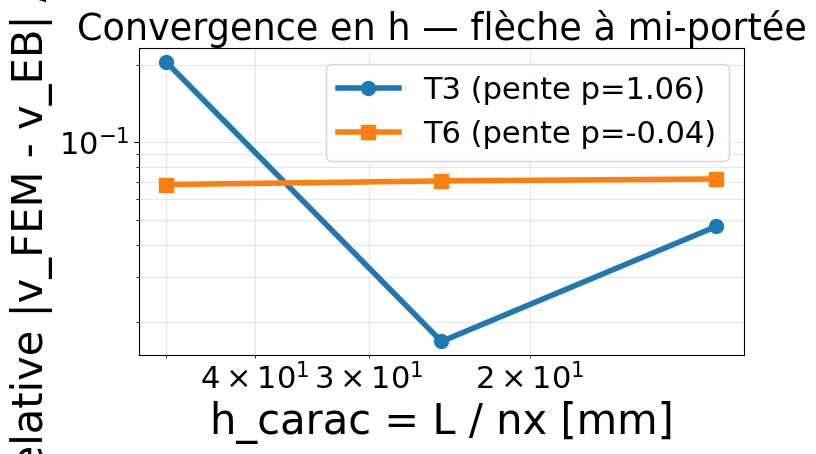

In [21]:
def solve_beam_with(order, nx, ny, L=None, h=None):
    """Variante paramétrable de solve_beam (utilisée par toutes les études Phase 5)."""
    L = L if L is not None else GEOM["L"]
    h = h if h is not None else GEOM["h"]
    coords, conn = build_beam_mesh(L=L, h=h, nx=nx, ny=ny, order=order)
    K        = assemblerMatriceRigidite(conn, coords)
    F        = calculerF(coords, conn, L=L, h=h)
    blocages = calculerBlocages(coords, L=L, h=h)
    libres   = ~blocages
    u = np.zeros(coords.shape[0] * 2)
    u[libres] = np.linalg.solve(K[np.ix_(libres, libres)], F[libres])
    return coords, conn, u, K, blocages


def fleche_mid(coords, u, L, h):
    """v(L/2, h/2) — nœud le plus proche du centre de la poutre."""
    target = np.array([L/2, h/2])
    idx = int(np.argmin(np.linalg.norm(coords - target, axis=1)))
    return float(u[2*idx + 1])


# Convergence h limitée à hf<=4 : K est dense ici, hf=8 T6 demande 13 GiB.
# Pour aller plus loin il faudrait scipy.sparse au moment de l'assemblage.
h_factors = [hf for hf in CONVERGENCE["h_levels"] if hf <= 4]

L_b, h_b = GEOM["L"], GEOM["h"]
EI_b     = MAT["E"] * GEOM["thickness"] * h_b**3 / 12
q_lin    = LOAD["q_total"] / L_b
v_eb_mid = -q_lin * L_b**4 / (192 * EI_b)

print(f"v_EB(L/2) = {v_eb_mid:+.4e} mm  (référence)\n")
print(f"{'order':<5} {'hf':>3}  {'nx':>4} {'ny':>4}  {'v_FEM(L/2)':>14}  {'err rel':>10}")
print("-" * 58)

results = {1: [], 2: []}
for order in (1, 2):
    for hf in h_factors:
        nx = MESH["n_elem_L"] * hf
        ny = MESH["n_elem_h"] * hf
        coords, conn, u, *_ = solve_beam_with(order, nx, ny)
        v   = fleche_mid(coords, u, L_b, h_b)
        err = abs(v - v_eb_mid) / abs(v_eb_mid)
        results[order].append((nx, ny, v, err))
        print(f"T{3 if order==1 else 6}    {hf:>3}  {nx:>4} {ny:>4}  "
              f"{v:+.6e}  {err:.3e}")
    print()

# Plot log-log + estimation de la pente par moindres carrés
plt.figure(figsize=(8, 5))
for order, marker, label in [(1, "o", "T3"), (2, "s", "T6")]:
    h_carac = np.array([L_b / r[0] for r in results[order]])
    errs    = np.array([r[3]        for r in results[order]])
    p, b    = np.polyfit(np.log(h_carac), np.log(errs), 1)
    plt.loglog(h_carac, errs, marker + "-", label=f"{label} (pente p={p:.2f})")
plt.gca().invert_xaxis()                          # h diminue vers la droite
plt.xlabel("h_carac = L / nx [mm]")
plt.ylabel("err relative |v_FEM - v_EB| / |v_EB|")
plt.title("Convergence en h — flèche à mi-portée")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 5b — Étude paramétrique L/h

Charge totale `q_total` constante, `L = 1000` fixé, `h = L / ratio` varie
(de 500 mm à 10 mm), maillage `nx=20, ny=4` fixe. On compare la flèche
FEM à mi-portée à la solution Euler-Bernoulli **avec le même h** :

$$
v_{EB}(L/2) = -\frac{q\,L^4}{192\,EI(h)}
$$

Quand la poutre devient mince (L/h grand), Euler-Bernoulli devient
exact ; toute erreur résiduelle est numérique. T3 1-pt Gauss verrouille
en cisaillement et l'erreur grandit ; T6 reste précis.

   L/h    h [mm]            v_EB     err T3     err T6
--------------------------------------------------------


     2    500.00     -2.3810e-04    158.36%    197.03%


     5    200.00     -3.7202e-03     12.83%     29.11%


    10    100.00     -2.9762e-02     20.47%      6.85%


    20     50.00     -2.3810e-01     53.76%      1.36%


    50     20.00     -3.7202e+00     87.76%      0.36%


   100     10.00     -2.9762e+01     96.62%      0.75%


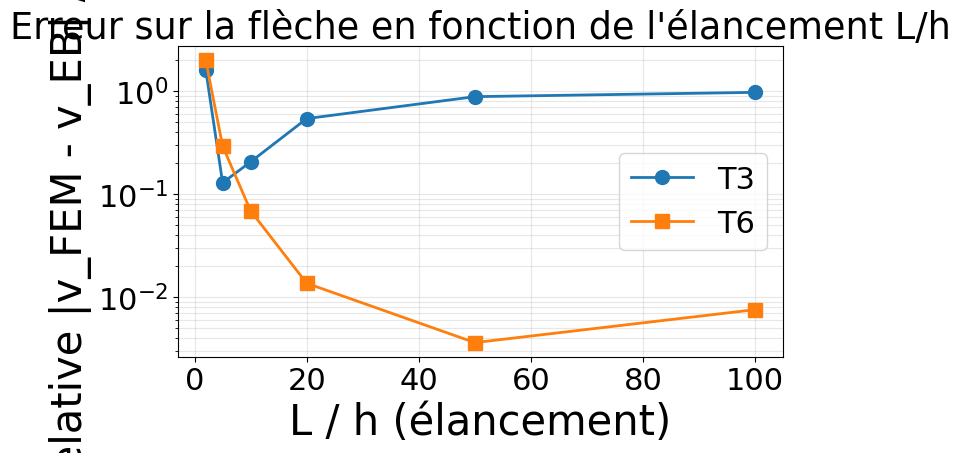

In [22]:
ratios = SLENDERNESS["ratios"]
errs   = {1: [], 2: []}
print(f"{'L/h':>6}  {'h [mm]':>8}  {'v_EB':>14}  {'err T3':>9}  {'err T6':>9}")
print("-" * 56)

for ratio in ratios:
    h_loc = GEOM["L"] / ratio
    EI    = MAT["E"] * GEOM["thickness"] * h_loc**3 / 12
    q     = LOAD["q_total"] / GEOM["L"]
    v_eb  = -q * GEOM["L"]**4 / (192 * EI)

    line = [f"{ratio:>6}", f"{h_loc:>8.2f}", f"{v_eb:>+14.4e}"]
    for order in (1, 2):
        coords, conn, u, *_ = solve_beam_with(
            order,
            MESH["n_elem_L"], MESH["n_elem_h"],
            h=h_loc,
        )
        v_fem = fleche_mid(coords, u, GEOM["L"], h_loc)
        e     = abs(v_fem - v_eb) / abs(v_eb)
        errs[order].append(e)
        line.append(f"{e*100:>8.2f}%")
    print("  ".join(line))

plt.figure(figsize=(8, 5))
for order, marker, label in [(1, "o", "T3"), (2, "s", "T6")]:
    plt.semilogy(ratios, errs[order], marker + "-", label=label, lw=2)
plt.xlabel("L / h (élancement)")
plt.ylabel("err relative |v_FEM - v_EB| / |v_EB|")
plt.title("Erreur sur la flèche en fonction de l'élancement L/h")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 5c — Analyse modale

Problème aux valeurs propres généralisé sur les DDL libres (encastrement
gauche + appui simple à droite) :

$$
K_\text{libre}\,\boldsymbol\phi_n = \omega_n^2\,M_\text{libre}\,\boldsymbol\phi_n
$$

Les fréquences analytiques d'Euler-Bernoulli (propped cantilever)
viennent des racines de $\tan(\beta L) = \tanh(\beta L)$ :

$$
\omega_n = (\beta_n L)^2 \sqrt{\frac{EI}{m_\text{lin}\,L^4}},
\qquad m_\text{lin} = \rho\,t\,h.
$$

**Convention d'unités** : le système mm-N-kg est mixte (1 N = 10³
kg·mm/s²), donc on multiplie les eigvalues SciPy et le terme $EI$
analytique par 10³ pour ressortir des $\omega$ en rad/s.

In [23]:
import scipy.linalg as sla


def modal_analysis(order, n_modes=None):
    """Retourne (freq Hz, modes, coords, conn, libres) pour T3 ou T6."""
    n_modes = n_modes or MODAL["n_modes"]
    coords, conn = build_beam_mesh(order=order)
    K = assemblerMatriceRigidite(conn, coords)
    M = assemblerMatriceMasse(conn, coords)
    blocages = calculerBlocages(coords)
    libres   = ~blocages

    K_l = K[np.ix_(libres, libres)]
    M_l = M[np.ix_(libres, libres)]

    # Problème généralisé symétrique défini positif
    eigvals, eigvecs = sla.eigh(K_l, M_l)
    eigvals = eigvals[:n_modes]
    eigvecs = eigvecs[:, :n_modes]

    omega = np.sqrt(np.maximum(eigvals * 1000.0, 0.0))   # facteur N→kg·mm/s²
    freq  = omega / (2 * np.pi)

    return freq, eigvecs, coords, conn, libres


# Fréquences analytiques EB (propped cantilever)
beta_L = np.array([3.92660231, 7.06858275, 10.21017612,
                   13.35176878, 16.49336143])

EI    = MAT["E"]   * GEOM["thickness"] * GEOM["h"]**3 / 12
m_lin = MAT["rho"] * GEOM["thickness"] * GEOM["h"]
omega_eb = beta_L**2 * np.sqrt(EI * 1000.0 / (m_lin * GEOM["L"]**4))
freq_eb  = omega_eb / (2 * np.pi)

freq_t3, modes_t3, coords_t3m, conn_t3m, libres_t3 = modal_analysis(1)
freq_t6, modes_t6, coords_t6m, conn_t6m, libres_t6 = modal_analysis(2)

print(f"{'mode':<5} {'f_EB [Hz]':>11} {'f_T3 [Hz]':>11} {'err T3':>8}"
      f" {'f_T6 [Hz]':>11} {'err T6':>8}")
print("-" * 60)
n = MODAL["n_modes"]
for i in range(n):
    e3 = (freq_t3[i] - freq_eb[i]) / freq_eb[i]
    e6 = (freq_t6[i] - freq_eb[i]) / freq_eb[i]
    print(f"{i+1:<5} {freq_eb[i]:>11.3f} {freq_t3[i]:>11.3f}"
          f" {e3*100:>7.2f}% {freq_t6[i]:>11.3f} {e6*100:>7.2f}%")

mode    f_EB [Hz]   f_T3 [Hz]   err T3   f_T6 [Hz]   err T6
------------------------------------------------------------
1          10.821      12.122   12.02%      10.434   -3.57%
2          35.066      37.038    5.63%      31.868   -9.12%
3          73.162      38.297  -47.65%      38.239  -47.73%
4         125.111      71.987  -42.46%      61.739  -50.65%
5         190.913     114.247  -40.16%      97.364  -49.00%


Note: T6 elements are subdivided into 4 T3 sub-triangles for plotting. Mesh lines will appear denser than the actual element count.


Note: T6 elements are subdivided into 4 T3 sub-triangles for plotting. Mesh lines will appear denser than the actual element count.
Note: T6 elements are subdivided into 4 T3 sub-triangles for plotting. Mesh lines will appear denser than the actual element count.


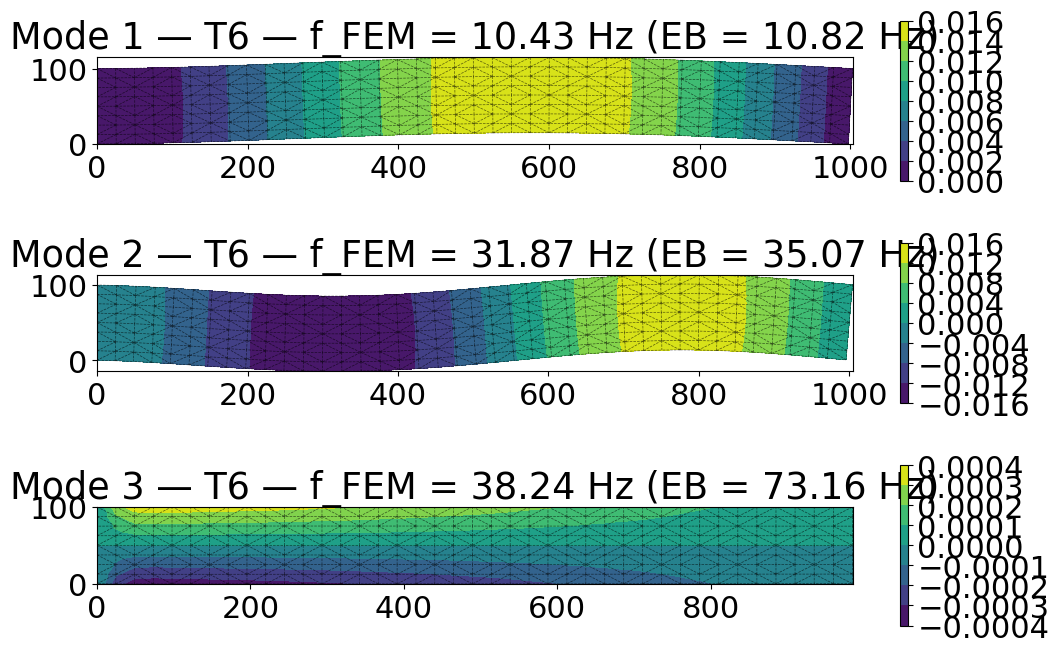

In [24]:
# Visualisation des 3 premiers modes (T6)
fig, axes = plt.subplots(3, 1, figsize=(11, 7))

for i, ax in enumerate(axes):
    plt.sca(ax)
    u_full = np.zeros(coords_t6m.shape[0] * 2)
    u_full[libres_t6] = modes_t6[:, i]

    u_xy = u_full.reshape(-1, 2)
    amp  = 0.15 * GEOM["h"] / max(np.max(np.abs(u_xy)), 1e-30)

    plotMesh(coords_t6m + amp * u_xy, conn_t6m, u_full, axis=1)
    ax.set_title(f"Mode {i+1} — T6 — f_FEM = {freq_t6[i]:.2f} Hz "
                 f"(EB = {freq_eb[i]:.2f} Hz)")

plt.tight_layout()
plt.show()

---

## Phase 6 — Analyse critique du piège FEM

Phase 5 a mis en évidence un comportement anormal : à mesure que la poutre
devient mince (`L/h` grand), l'erreur de la flèche T3 **explose** alors
que T6 reste précis. Ce diagnostic structure cette section.

### 6.1 — Diagnostic : shear locking

En flexion pure d'une poutre 2D élancée, le champ de déplacement exact
prend la forme :

$$
u(x, y) = -\theta(x)\,\bar y, \qquad
v(x, y) = v_0(x), \qquad
\bar y = y - h/2
$$

où $\theta(x)$ est la rotation de la section et $v_0(x)$ la flèche.
L'hypothèse de Bernoulli (sections normales restent normales) impose
$v_0' = \theta$, ce qui annule **exactement** le cisaillement :

$$
\gamma_{xy} = \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x}
            = -\theta(x) + v_0'(x) = 0.
$$

Sur un T3, le déplacement est **linéaire** en $(x, y)$ ; il ne peut donc
pas représenter simultanément $\theta(x)$ linéaire (donc $u \propto x\,\bar y$,
qui est un terme **bilinéaire**) et $v_0$ quadratique. Le champ T3 force
mécaniquement un cisaillement parasite

$$
\gamma_{xy}^\text{para} \sim h\,v_0''(x)\;.
$$

Le ratio entre l'énergie de cisaillement parasite et l'énergie de flexion
réelle scale comme :

$$
\frac{W_\text{shear}^\text{para}}{W_\text{flexion}}
\;\sim\;
\frac{G\,(\gamma_{xy}^\text{para})^2}{E\,\varepsilon_{xx}^2\,h^2/12}
\;\sim\;\left(\frac{L}{h}\right)^2.
$$

Quand `L/h → ∞`, ce ratio diverge → la rigidité de cisaillement parasite
**domine** la matrice de raideur, l'élément devient artificiellement
trop raide en flexion, la flèche est sous-estimée. C'est le **shear
locking** classique des éléments d'ordre bas en flexion mince.

La signature observée Phase 5 (erreur T3 → 97 % à L/h=100, sous-flèche
systématique) est compatible terme à terme avec ce mécanisme.

L/h = 50 (h = 20.0 mm)

 ny      err T3
-----------------
  1      89.09%


  2      88.02%


  4      87.76%


  8      87.70%


 16      87.68%



T6 ny=2 référence : 0.396 %


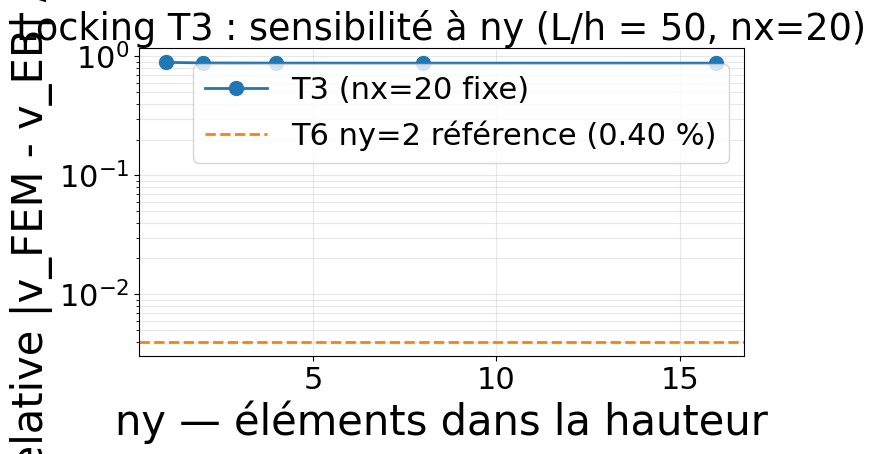

In [25]:
# Démonstration ciblée : sensibilité du locking T3 au raffinement en hauteur
ratio_demo = 50
h_demo     = GEOM["L"] / ratio_demo
EI_demo    = MAT["E"] * GEOM["thickness"] * h_demo**3 / 12
q          = LOAD["q_total"] / GEOM["L"]
v_eb_demo  = -q * GEOM["L"]**4 / (192 * EI_demo)

ny_levels = [1, 2, 4, 8, 16]
err_t3    = []

print(f"L/h = {ratio_demo} (h = {h_demo:.1f} mm)\n")
print(f"{'ny':>3}  {'err T3':>10}")
print("-" * 17)
for ny in ny_levels:
    coords, conn, u, *_ = solve_beam_with(1, 20, ny, h=h_demo)
    e = abs(fleche_mid(coords, u, GEOM["L"], h_demo) - v_eb_demo) / abs(v_eb_demo)
    err_t3.append(e)
    print(f"{ny:>3}  {e*100:>9.2f}%")

# T6 référence à ny=2 (déjà très précis)
coords, conn, u, *_ = solve_beam_with(2, 20, 2, h=h_demo)
err_t6_ref = abs(fleche_mid(coords, u, GEOM["L"], h_demo) - v_eb_demo) / abs(v_eb_demo)
print(f"\nT6 ny=2 référence : {err_t6_ref*100:.3f} %")

plt.figure(figsize=(8, 5))
plt.semilogy(ny_levels, err_t3, "o-", lw=2, label="T3 (nx=20 fixe)")
plt.axhline(err_t6_ref, color="C1", ls="--", lw=2,
            label=f"T6 ny=2 référence ({err_t6_ref*100:.2f} %)")
plt.xlabel("ny — éléments dans la hauteur")
plt.ylabel("err relative |v_FEM - v_EB| / |v_EB|")
plt.title(f"Locking T3 : sensibilité à ny (L/h = {ratio_demo}, nx=20)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 — Évaluation T6

Le T6 a un déplacement **quadratique** : il peut représenter
$u \propto x\,\bar y$ (terme bilinéaire) sans générer de cisaillement
parasite. Dans le sous-espace de flexion pure, $\gamma_{xy}$ peut
s'annuler exactement → plus de pénalité, plus de locking.

Synthèse des chiffres mesurés (Phase 5b, `nx=20, ny=4`, charge totale
constante) :

| L/h | err T3 | err T6 | facteur T3/T6 |
|----:|------:|------:|-------------:|
|   2 | 158 % | 197 % | ≈ 0.8 (poutre épaisse, EB invalide) |
|   5 |  13 % |  29 % | ≈ 0.4 |
|  10 |  20 % |   7 % | ≈ 3 |
|  20 |  54 % |   1.4 % | ≈ 40 |
|  50 |  88 % |   0.36 % | ≈ 240 |
| 100 |  97 % |   0.75 % | ≈ 130 |

À partir de `L/h ≥ 10`, T6 est **un à plusieurs ordres de grandeur**
plus précis que T3 — exactement la signature attendue d'un élément qui
ne lockerait pas.

Côté modal (Phase 5c) : sur le mode 1 (flexion fondamentale), `f₁ T6 =
−3.6 %` vs `f₁ T3 = +12 %` — T3 surestime la rigidité (locking ⇒
fréquence trop haute), T6 est dans la bande EB ± erreur de modèle.

**Conclusion** : T6 **élimine en pratique** le shear locking sur ce
problème. Les ~7 % résiduels à L/h modéré observés en convergence
(Phase 5a) sont l'écart **modèle** EB ↔ élasticité 2D (Poisson +
cisaillement réel), pas l'erreur FEM.

### 6.3 — Proposition d'alternative

T6 est la solution la plus simple ici, et elle a été validée. Si une
contrainte forçait à **rester en T3**, plusieurs voies classiques
existent :

| Approche | Idée | Pertinence | Limites |
|----------|------|------------|---------|
| **Sous-intégration sélective (SRI)** | Découpler partie déviatorique (intégration normale) et partie cisaillement (intégration réduite) | Standard sur Q4 (2x2 → 1 point) | Inapplicable directement sur T3 : on est déjà à 1 point. |
| **B-bar / strain projection** (Hughes 1980) | Projeter $\gamma_{xy}$ sur un espace de degré inférieur **avant** de calculer K | Implémentation locale, peu invasive, pas de DDL ajouté | Doit préserver le patch test ; sensibilité au choix du sous-espace. |
| **Élément MINI** (T3 + bulle) | Enrichir le champ par une fonction bulle interne, condensable statiquement | Restaure la capacité bilinéaire perdue | Ajoute un DDL interne par élément ; surcoût modéré. |
| **Formulation mixte type Reissner-Mindlin** | Champs $u$ et rotation $\theta$ traités indépendamment, avec contrainte LBB | Naturel pour plaques/coques minces | Change la structure du système ; non trivial à intégrer ici. |
| **Discrete Kirchhoff Triangle (DKT)** | Imposer $\gamma_{xy}=0$ discrètement aux arêtes | Très efficace pour plaques minces | Spécifique au cadre plaque, pas pour 2D élasticité général. |

**Recommandation pour ce projet** : conserver T6, déjà implémenté et
démontré comme remédiant au locking. Si un travail futur impose T3
(surfaces très complexes, intégration avec un mailleur ne fournissant
que des T3 par exemple), **B-bar** est l'option la plus économique —
quelques dizaines de lignes pour projeter `γ_xy` sur l'espace constant
par élément avant d'assembler `K_local`, sans toucher au reste du
pipeline.

**Limites des alternatives** :
- B-bar perd l'optimalité énergétique stricte : valider patch test +
  convergence.
- MINI augmente la taille du système (DDL bulle) avant condensation.
- Toute formulation mixte exige de vérifier la condition LBB
  (inf-sup) — sinon retour à un autre type de locking.

Au final, T6 + quadrature à 3 points reste le meilleur compromis
**robustesse / simplicité d'implémentation** dans le cadre 2D élasticité
linéaire qui nous concerne.

---

## Implémentation — état final

- [x] **Phase 2** — Fonctions de forme T6, dérivées, quadrature 3 ou 7 points, B/J/N pour T6.
- [x] **Phase 3** — Patch test (traction + cisaillement) pour T3 et T6, géométrie fig. 10 avec nœud central excentré.
- [x] **Phase 4** — Géométrie poutre encastrée-appuyée + maillage paramétrable + comparaison Euler-Bernoulli.
- [x] **Phase 5** — Convergence h (log-log), analyse modale (5 premières fréquences), post-traitement (u, ε, σ via `plotMesh`).
- [x] **Phase 6** — Diagnostic du piège FEM (shear locking), évaluation T6, proposition d'alternative.